In [196]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

# Caminho relativo (funciona de qualquer lugar)
# data_path = Path("..") / "data" / "raw" / "gaussianas.csv"
# df = pd.read_csv(data_path)

In [197]:
def plot_grid(data, labels):
    fig, ax = plt.subplots()
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", edgecolor="k")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Dados Gaussianos")
    plt.grid()
    plt.show()


def gen_data(params: dict) -> np.ndarray:
    """Gera um DataFrame com duas classes de dados gaussianos."""

    mean1 = params["mean1"]
    mean2 = params["mean2"]
    cov = params["cov"]
    priors = params["priors"]
    n_samples = params["n_samples"]
    seed = params["seed"]

    assert round(sum(priors), 2) == 1, "Os priors devem somar 1."

    class_1_pdf = multivariate_normal(mean1, cov)
    class_2_pdf = multivariate_normal(mean2, cov)

    class_1_samples = class_1_pdf.rvs(int(n_samples * priors[0]), random_state=seed)
    class_2_samples = class_2_pdf.rvs(int(n_samples * priors[1]), random_state=seed)

    data = np.vstack((class_1_samples, class_2_samples))
    labels = np.array([0] * len(class_1_samples) + [1] * len(class_2_samples))

    # Trocar amostragem por .rvs para gerar amostras de forma analitica.

    return data, labels


def get_posterior(params: dict, x):
    """Calcula a probabilidade a posteriori usando a distribuição normal multivariada."""
    prob_1 = multivariate_normal.pdf(x, mean=params["mean1"], cov=params["cov"])
    prob_2 = multivariate_normal.pdf(x, mean=params["mean2"], cov=params["cov"])
    priors = params["priors"]

    numerators = np.stack([prob_1 * priors[0], prob_2 * priors[1]], axis=1)
    return numerators / numerators.sum(axis=1, keepdims=True)


# Pensar no caso de 100 classes. Pensar na forma vetorial e broadcast.


def get_preds(x, params):

    posteriors = get_posterior(params, x)
    predicions = np.argmax(posteriors, axis=1)
    confidence = np.max(posteriors, axis=1)
    return predicions, confidence

    # Argmax da posterior
    # Func de confiança chow, rank de probabilidade.

In [258]:
params = {
    "mean1": (-1, -1),
    "mean2": (1, 1),
    "cov": [[1, 0], [0, 1]],
    "priors": [0.2, 0.8],
    "n_samples": 1000,
    "seed": 77,
}

data, labels = gen_data(params)

classifications, confidence = get_preds(data, params)

Acurácia: 0.94


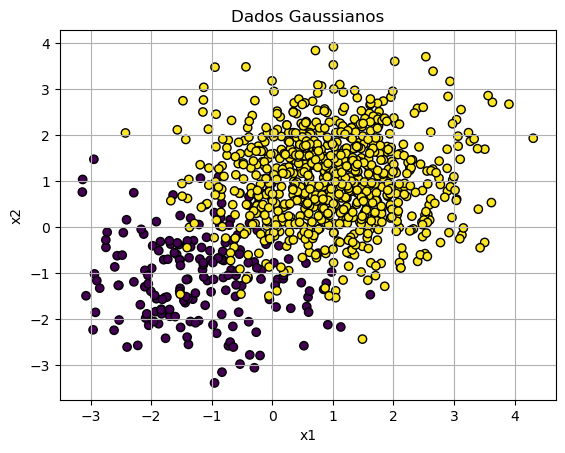

In [259]:
accuracy = np.mean(classifications == labels)
print(f"Acurácia: {accuracy:.2f}")

plot_grid(data, labels)

In [260]:
# plot RC curve.

# rank de probabilidade, func de confiança
index = np.argsort(confidence)[::-1]
sorted_confidence = confidence[index]
sorted_labels = labels[index]
sorted_predictions = classifications[index]
sorted_errors = sorted_predictions != sorted_labels

# teste de argsort
# display(sorted_confidence[:5])
# plt.plot(sorted_confidence[:100], marker="o")
# plt.xlabel("Índice")

In [261]:
coverages = np.linspace(0.1, 1, 10)

error_std = np.array([])
coberturas = np.array([])
bers = np.array([])
wgs = np.array([])


for k in coverages:
    # Cobertura
    index_k = int(k * len(sorted_labels))
    classes = np.unique(sorted_labels)
    if np.unique(sorted_labels[:index_k], return_counts=True)[1].min() > 5:
        # Selecionando os erros para a cobertura k
        errors_k = sorted_errors[:index_k]
        coberturas = np.append(coberturas, k)

        # error padrão da cobertura k
        error_rate_k = np.mean(errors_k)
        error_std = np.append(error_std, error_rate_k)

        # Erros por classe
        erros = [
            np.mean(sorted_errors[:index_k][sorted_labels[:index_k] == classe])
            for classe in classes
        ]

        # Erro Balanceado
        ber_k = np.mean(erros)
        bers = np.append(bers, ber_k)

        # Worst-group error
        wgs_k = np.max(erros)
        wgs = np.append(wgs, wgs_k)

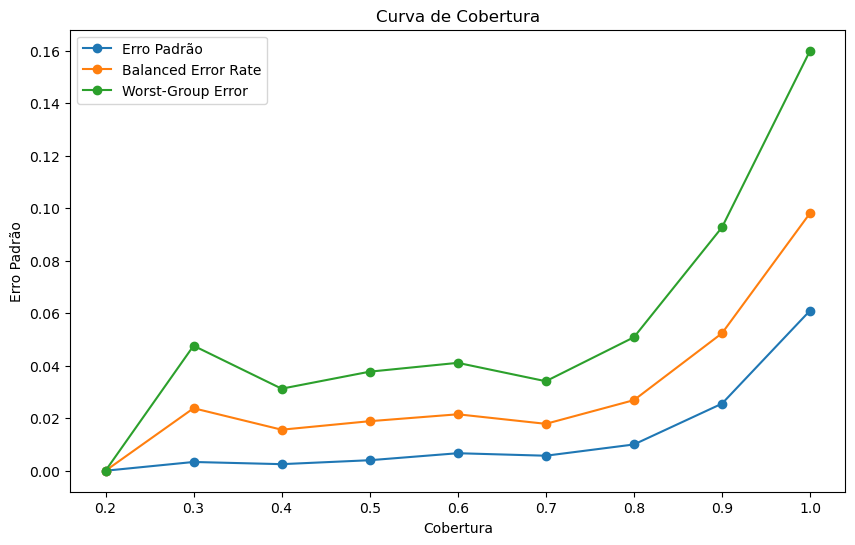

In [262]:
plt.figure(figsize=(10, 6))
plt.plot(coberturas, error_std, marker="o", label="Erro Padrão")
plt.plot(coberturas, bers, marker="o", label="Balanced Error Rate")
plt.plot(coberturas, wgs, marker="o", label="Worst-Group Error")
plt.xlabel("Cobertura")
plt.ylabel("Erro Padrão")
plt.title("Curva de Cobertura")
plt.legend()
plt.show()